In [200]:
import pandas as pd

In [201]:
scheme_df = pd.read_csv('../data/mutual_fund_data.csv')

In [202]:
nav_df = pd.read_parquet('../data/mutual_fund_nav_history.parquet')
nav_df = nav_df.reset_index()

In [203]:
equity_large_cap = scheme_df[(scheme_df['Scheme_Category'] == 'Equity Scheme - Large Cap Fund') & (scheme_df['Scheme_NAV_Name'].str.contains('Growth'))]
date_filtered_nav = nav_df[(nav_df['Date'] >= pd.to_datetime('2018-01-01')) & (nav_df['Date'] < pd.to_datetime('2025-09-01'))]

In [204]:
equity_schema_nav = date_filtered_nav.merge(equity_large_cap, on='Scheme_Code', how='inner', suffixes=('_nav', '_scheme'))[['Scheme_Code', 'Date', 'NAV_nav', 'Scheme_Name', 'Launch_Date', 'Closure_Date']]

In [205]:
# per scheme reporting coverage - per day count of schemes reporting
# per scheme how many days of coverage

per_scheme_reporting = equity_schema_nav.groupby('Scheme_Code')['Date'].count().reset_index()
per_scheme_reporting.columns = ['Scheme_Code', 'reporting_days']
per_scheme_reporting.sort_values(by='reporting_days')
per_scheme_reporting.describe()

,Scheme_Code,reporting_days
count,67.000000,67.000000
mean,124588.985075,1542.044776
std,18058.822485,555.300176
min,100219.000000,97.000000
25%,110367.000000,1169.500000
50%,119160.000000,1880.000000
75%,146550.000000,1880.000000
max,153239.000000,1884.000000


In [206]:
filtered_schemes = per_scheme_reporting[per_scheme_reporting['reporting_days'] >= 1160]
filtered_schemes_nav = equity_schema_nav[equity_schema_nav['Scheme_Code'].isin(filtered_schemes['Scheme_Code'])]


In [207]:
filtered_schemes_nav = filtered_schemes_nav.sort_values(by=['Scheme_Code', 'Date'])
filtered_schemes_nav['Prev_date'] = filtered_schemes_nav.groupby('Scheme_Code')['Date'].shift(1)
filtered_schemes_nav['Gaps'] = filtered_schemes_nav['Date'] - filtered_schemes_nav['Prev_date']

In [208]:
filtered_schemes_nav['Gaps'].describe()

count                        92000
mean     1 days 11:43:20.765217391
std      0 days 21:23:48.466554141
min                1 days 00:00:00
25%                1 days 00:00:00
50%                1 days 00:00:00
75%                1 days 00:00:00
max                5 days 00:00:00
Name: Gaps, dtype: object

In [209]:
agg_df = filtered_schemes_nav.groupby('Date')['NAV_nav'].mean().reset_index()
agg_df.columns = ['Date', 'cat_avg_nav']
agg_df

,Date,cat_avg_nav
0,2018-01-01,122.571343
1,2018-01-02,122.465454
2,2018-01-03,122.657974
3,2018-01-04,123.540070
4,2018-01-05,124.303313
...,...,...
1885,2025-08-21,280.217698
1886,2025-08-22,278.398066
1887,2025-08-26,276.445414
1888,2025-08-28,273.754766


In [210]:
# Check missing dates

agg_df['Date'] = pd.to_datetime(agg_df['Date'])

dates = pd.Series(sorted(agg_df['Date'].unique()))

full_range = pd.date_range(
    start=agg_df['Date'].min(),
    end = agg_df['Date'].max(),
    freq='D'
)

missing_dates = full_range.difference(dates)

print(f"Total missing dates: {len(missing_dates)}")

missing_dates.day_name().value_counts()

Total missing dates: 908


Saturday     394
Sunday       394
Friday        27
Wednesday     25
Monday        25
Thursday      22
Tuesday       21
Name: count, dtype: int64

In [211]:
agg_df['pct_change'] = agg_df['cat_avg_nav'].pct_change()

agg_df['pct_change'].describe()

count    1889.000000
mean        0.007969
std         0.180205
min        -0.824405
25%        -0.004269
50%         0.000843
75%         0.006044
max         4.747345
Name: pct_change, dtype: float64

In [212]:
scheme_count = filtered_schemes_nav.groupby('Date')['Scheme_Code'].nunique().reset_index()
scheme_count.columns = ['Date', 'scheme_count']

In [213]:
scheme_count['scheme_count'].describe()

count    1890.000000
mean       48.703704
std         3.624813
min         2.000000
25%        48.000000
50%        50.000000
75%        50.000000
max        50.000000
Name: scheme_count, dtype: float64

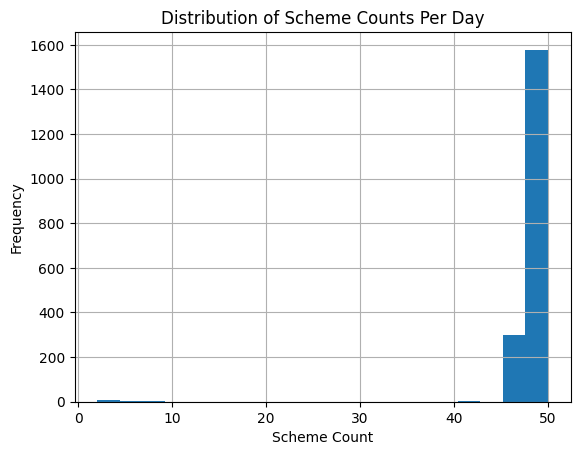

In [214]:
import matplotlib.pyplot as plt

scheme_count['scheme_count'].hist(bins=20)

plt.title("Distribution of Scheme Counts Per Day")
plt.xlabel("Scheme Count")
plt.ylabel("Frequency")

plt.show()

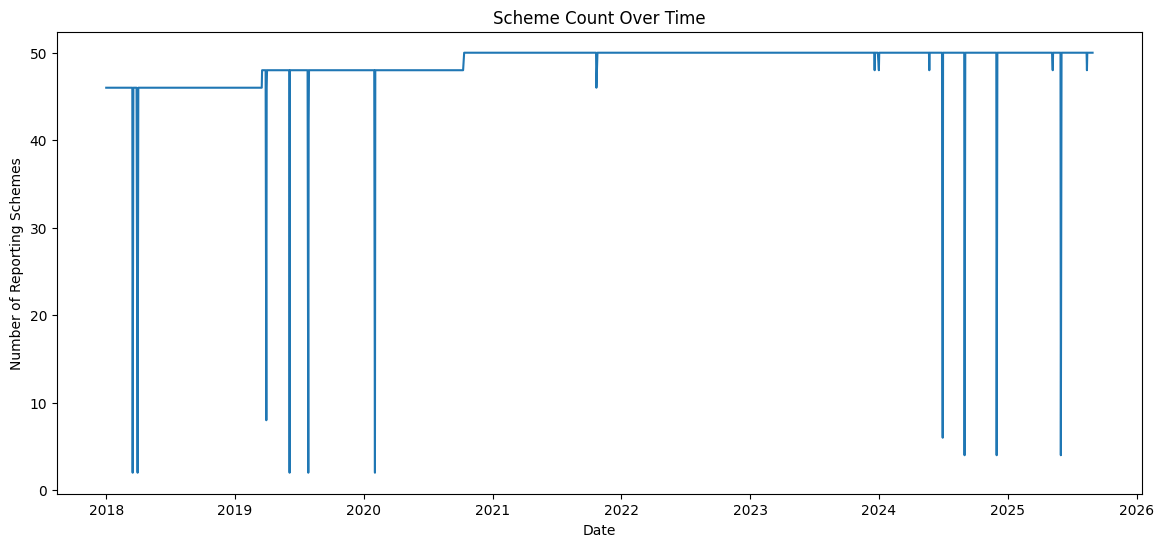

In [215]:
plt.figure(figsize=(14,6))

plt.plot(
    scheme_count['Date'],
    scheme_count['scheme_count']
)

plt.title("Scheme Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reporting Schemes")

plt.show()

In [217]:
scheme_count['count_diff'] = (
    scheme_count['scheme_count']
    .diff()
)

scheme_count['Day'] = scheme_count['Date'].dt.day_name()

scheme_count.sort_values(
    by=['count_diff', 'Date']
).head(45)

,Date,scheme_count,count_diff,Day
353,2019-06-05,2,-46.0,Wednesday
391,2019-07-28,2,-46.0,Sunday
517,2020-02-02,2,-46.0,Sunday
1648,2024-08-31,4,-46.0,Saturday
1710,2024-11-30,4,-46.0,Saturday
1833,2025-05-31,4,-46.0,Saturday
52,2018-03-17,2,-44.0,Saturday
61,2018-03-31,2,-44.0,Saturday
1604,2024-06-30,6,-44.0,Sunday
309,2019-03-31,8,-40.0,Sunday


In [218]:
cleaned_equity_aggregate_dates = scheme_count[scheme_count['scheme_count'] > 45]['Date'].unique()
cleaned_filtered_schemes_nav = filtered_schemes_nav[filtered_schemes_nav['Date'].isin(cleaned_equity_aggregate_dates)]

In [219]:
cleaned_filtered_schemes_nav['Gaps'].describe()

count                        91922
mean     1 days 11:42:20.701899436
std      0 days 21:23:25.787882126
min                1 days 00:00:00
25%                1 days 00:00:00
50%                1 days 00:00:00
75%                1 days 00:00:00
max                5 days 00:00:00
Name: Gaps, dtype: object

In [224]:
cleaned_agg_df = cleaned_filtered_schemes_nav.groupby('Date')['NAV_nav'].mean().reset_index()
cleaned_agg_df.columns = ['Date', 'category_avg_nav']

cleaned_agg_df['pct_change'] = cleaned_agg_df['category_avg_nav'].pct_change()
cleaned_agg_df['pct_change'].describe()

count    1878.000000
mean        0.000496
std         0.011772
min        -0.132741
25%        -0.004231
50%         0.000836
75%         0.005953
max         0.140230
Name: pct_change, dtype: float64

In [225]:
cleaned_agg_df = cleaned_agg_df[[
    'Date',
    'category_avg_nav'
]]

In [226]:
cleaned_agg_df.to_parquet("../data/clean/equity_schema_nav.parqet")